# MindTune EEG Data Analysis

Comprehensive analysis of EEG brainwave data with event and emotion markers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Load Data

In [2]:
df = pd.read_csv('all_sessions_eeg_with_markers.csv')
print(f"Loaded {len(df):,} rows from {df['session_id'].nunique()} sessions")
print(f"Columns: {len(df.columns)}")
df.head()

Loaded 11,945 rows from 65 sessions
Columns: 36


,source_folder,source_session_path,timestamp_ms,session_id,participant_id,signal_quality,attention,meditation,delta,theta,...,ev_tech_issue,annotator_confidence,marker_emotion,marker_emotion_confidence,marker_ev_speaking_active,marker_ev_question_active,marker_ev_scolded_active,marker_ev_praised_active,marker_ev_qna_active,marker_ev_tech_issue_active
0,sessions,sessions/0054,1774857972940,0054,P0054,51,77,97,393129,7261,...,0,2,NaN,NaN,0,0,0,0,0,0
1,sessions,sessions/0054,1774857973920,0054,P0054,51,77,97,139346,70478,...,0,2,NaN,NaN,0,0,0,0,0,0
2,sessions,sessions/0054,1774857976914,0054,P0054,25,77,97,433,148,...,0,2,NaN,NaN,0,0,0,0,0,0
3,sessions,sessions/0054,1774857977910,0054,P0054,25,77,97,765093,36482,...,1,2,NaN,NaN,0,0,0,0,0,1
4,sessions,sessions/0054,1774857978884,0054,P0054,51,77,97,2010865,230926,...,1,2,NaN,NaN,0,0,0,0,0,1


In [3]:
# Define column groups
bands = ['delta', 'theta', 'low_alpha', 'high_alpha', 'low_beta', 'high_beta', 'low_gamma', 'mid_gamma']
events = ['ev_speaking', 'ev_question', 'ev_scolded', 'ev_praised', 'ev_qna', 'ev_tech_issue']
marker_events = ['marker_ev_speaking_active', 'marker_ev_question_active', 'marker_ev_scolded_active', 
                 'marker_ev_praised_active', 'marker_ev_qna_active', 'marker_ev_tech_issue_active']
emotions = ['emo_calm', 'emo_stressed', 'emo_delighted', 'emo_angry', 'emo_unknown']

print("Data summary:")
df.describe()

Data summary:


,timestamp_ms,signal_quality,attention,meditation,delta,theta,low_alpha,high_alpha,low_beta,high_beta,...,ev_qna,ev_tech_issue,annotator_confidence,marker_emotion_confidence,marker_ev_speaking_active,marker_ev_question_active,marker_ev_scolded_active,marker_ev_praised_active,marker_ev_qna_active,marker_ev_tech_issue_active
count,1.194500e+04,11945.000000,11945.000000,11945.000000,1.194500e+04,1.194500e+04,1.194500e+04,1.194500e+04,1.194500e+04,1.194500e+04,...,11945.000000,11945.000000,11945.000000,9350.0,11945.000000,11945.000000,11945.000000,11945.000000,11945.000000,11945.000000
mean,1.774859e+12,31.506404,31.393219,33.028631,8.481109e+05,3.154744e+05,1.036696e+05,9.828013e+04,7.678077e+04,6.758308e+04,...,0.402846,0.092256,2.011637,2.0,0.449393,0.335705,0.081122,0.003516,0.402846,0.092256
std,5.814793e+06,47.499323,29.219557,29.415616,6.374457e+05,3.909331e+05,1.715777e+05,1.634204e+05,1.307793e+05,1.135626e+05,...,0.490491,0.289399,0.107248,0.0,0.497453,0.472256,0.273034,0.059195,0.490491,0.289399
min,1.774849e+12,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,2.000000,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.774854e+12,0.000000,0.000000,0.000000,3.472530e+05,6.409100e+04,1.469700e+04,1.326300e+04,1.109700e+04,9.158000e+03,...,0.000000,0.000000,2.000000,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.774856e+12,26.000000,34.000000,37.000000,7.160950e+05,1.688280e+05,4.249700e+04,3.863300e+04,3.129200e+04,2.659300e+04,...,0.000000,0.000000,2.000000,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.774864e+12,51.000000,54.000000,56.000000,1.201200e+06,4.061290e+05,1.181890e+05,1.123120e+05,8.557200e+04,7.768900e+04,...,1.000000,0.000000,2.000000,2.0,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.774871e+12,200.000000,100.000000,100.000000,4.017698e+06,3.346457e+06,2.896245e+06,2.523598e+06,1.830033e+06,1.582280e+06,...,1.000000,1.000000,3.000000,2.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 2. Signal Quality Analysis

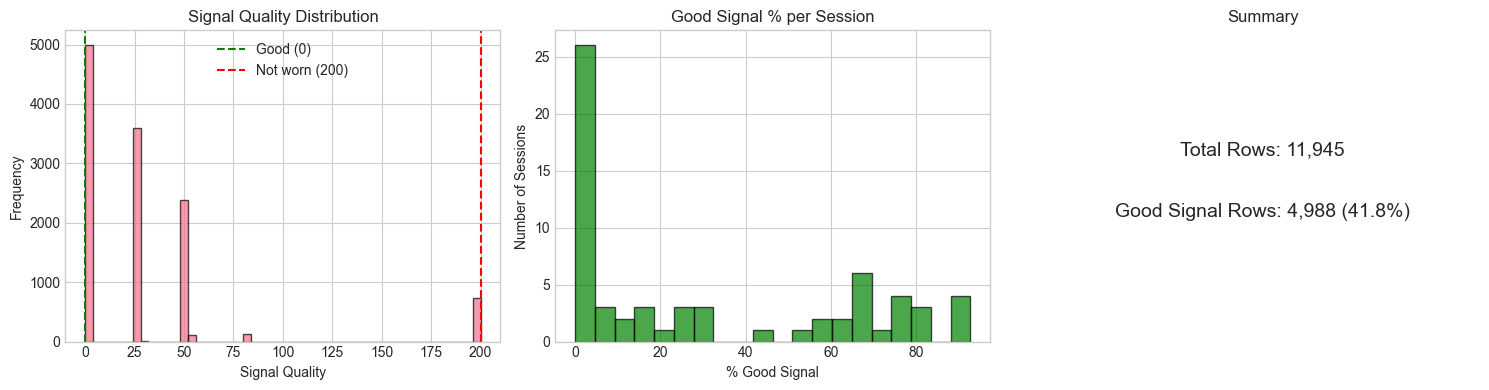


Using 4,988 rows with good signal quality for analysis


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Signal quality distribution
axes[0].hist(df['signal_quality'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='green', linestyle='--', label='Good (0)')
axes[0].axvline(x=200, color='red', linestyle='--', label='Not worn (200)')
axes[0].set_xlabel('Signal Quality')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Signal Quality Distribution')
axes[0].legend()

# Good signal % by session
good_pct = df.groupby('session_id').apply(lambda x: (x['signal_quality'] == 0).mean() * 100)
axes[1].hist(good_pct, bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('% Good Signal')
axes[1].set_ylabel('Number of Sessions')
axes[1].set_title('Good Signal % per Session')

# Summary stats
good_total = (df['signal_quality'] == 0).sum()
good_pct_total = (df['signal_quality'] == 0).mean() * 100
axes[2].text(0.5, 0.6, f'Total Rows: {len(df):,}', ha='center', fontsize=14, transform=axes[2].transAxes)
axes[2].text(0.5, 0.4, f'Good Signal Rows: {good_total:,} ({good_pct_total:.1f}%)', ha='center', fontsize=14, transform=axes[2].transAxes)
axes[2].axis('off')
axes[2].set_title('Summary')

plt.tight_layout()
plt.show()

# Filter for good signal
df_good = df[df['signal_quality'] == 0].copy()
print(f"\nUsing {len(df_good):,} rows with good signal quality for analysis")

## 3. Attention & Meditation Overview

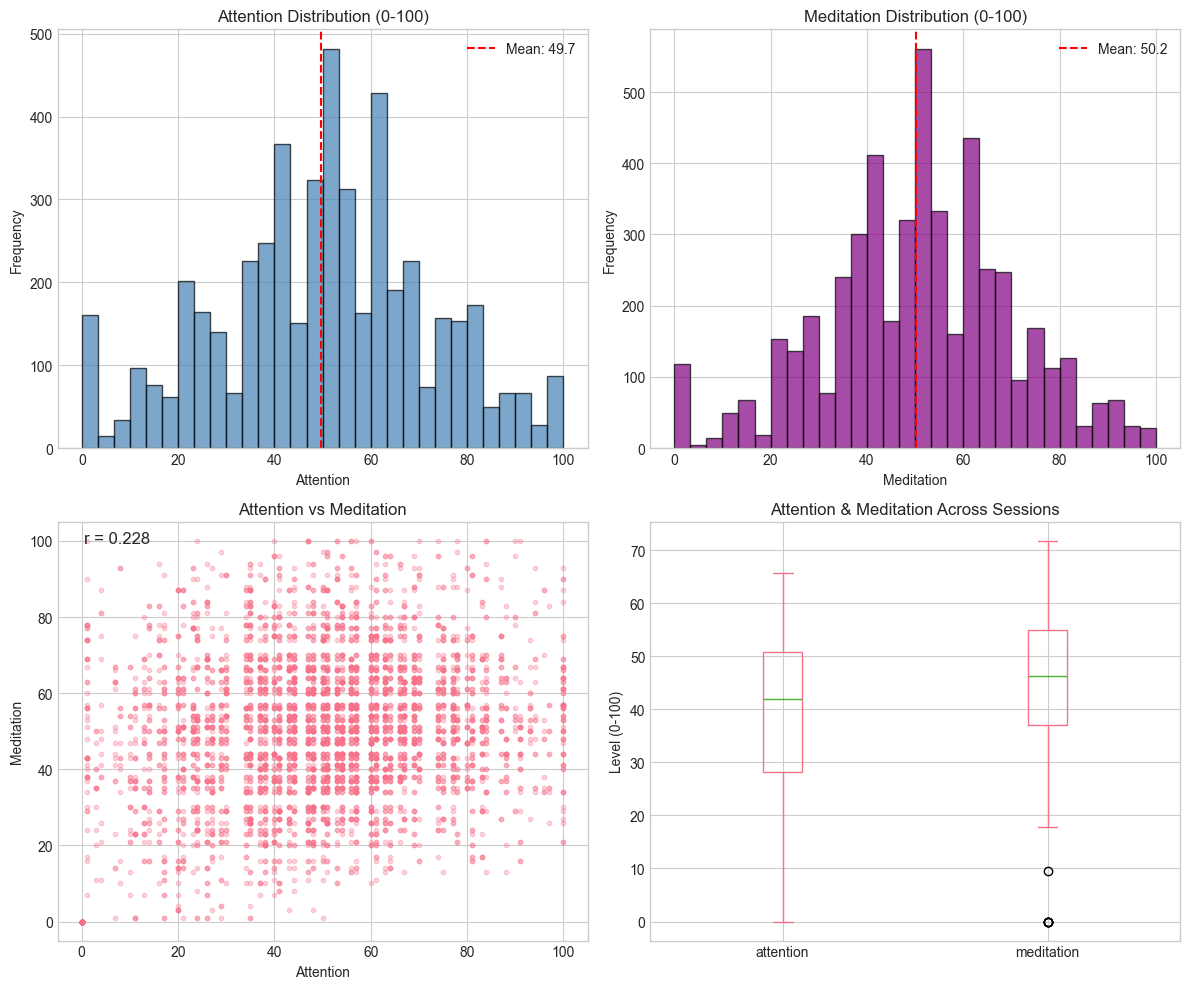

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Attention distribution
axes[0, 0].hist(df_good['attention'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_good['attention'].mean(), color='red', linestyle='--', label=f'Mean: {df_good["attention"].mean():.1f}')
axes[0, 0].set_xlabel('Attention')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Attention Distribution (0-100)')
axes[0, 0].legend()

# Meditation distribution
axes[0, 1].hist(df_good['meditation'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[0, 1].axvline(df_good['meditation'].mean(), color='red', linestyle='--', label=f'Mean: {df_good["meditation"].mean():.1f}')
axes[0, 1].set_xlabel('Meditation')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Meditation Distribution (0-100)')
axes[0, 1].legend()

    # Scatter
axes[1, 0].scatter(df_good['attention'], df_good['meditation'], alpha=0.3, s=10)
axes[1, 0].set_xlabel('Attention')
axes[1, 0].set_ylabel('Meditation')
axes[1, 0].set_title('Attention vs Meditation')
corr = df_good['attention'].corr(df_good['meditation'])
axes[1, 0].annotate(f'r = {corr:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)

# By session boxplot
session_means = df_good.groupby('session_id')[['attention', 'meditation']].mean()
session_means.plot(kind='box', ax=axes[1, 1])
axes[1, 1].set_ylabel('Level (0-100)')
axes[1, 1].set_title('Attention & Meditation Across Sessions')

plt.tight_layout()
plt.show()

## 4. Brainwave Band Analysis

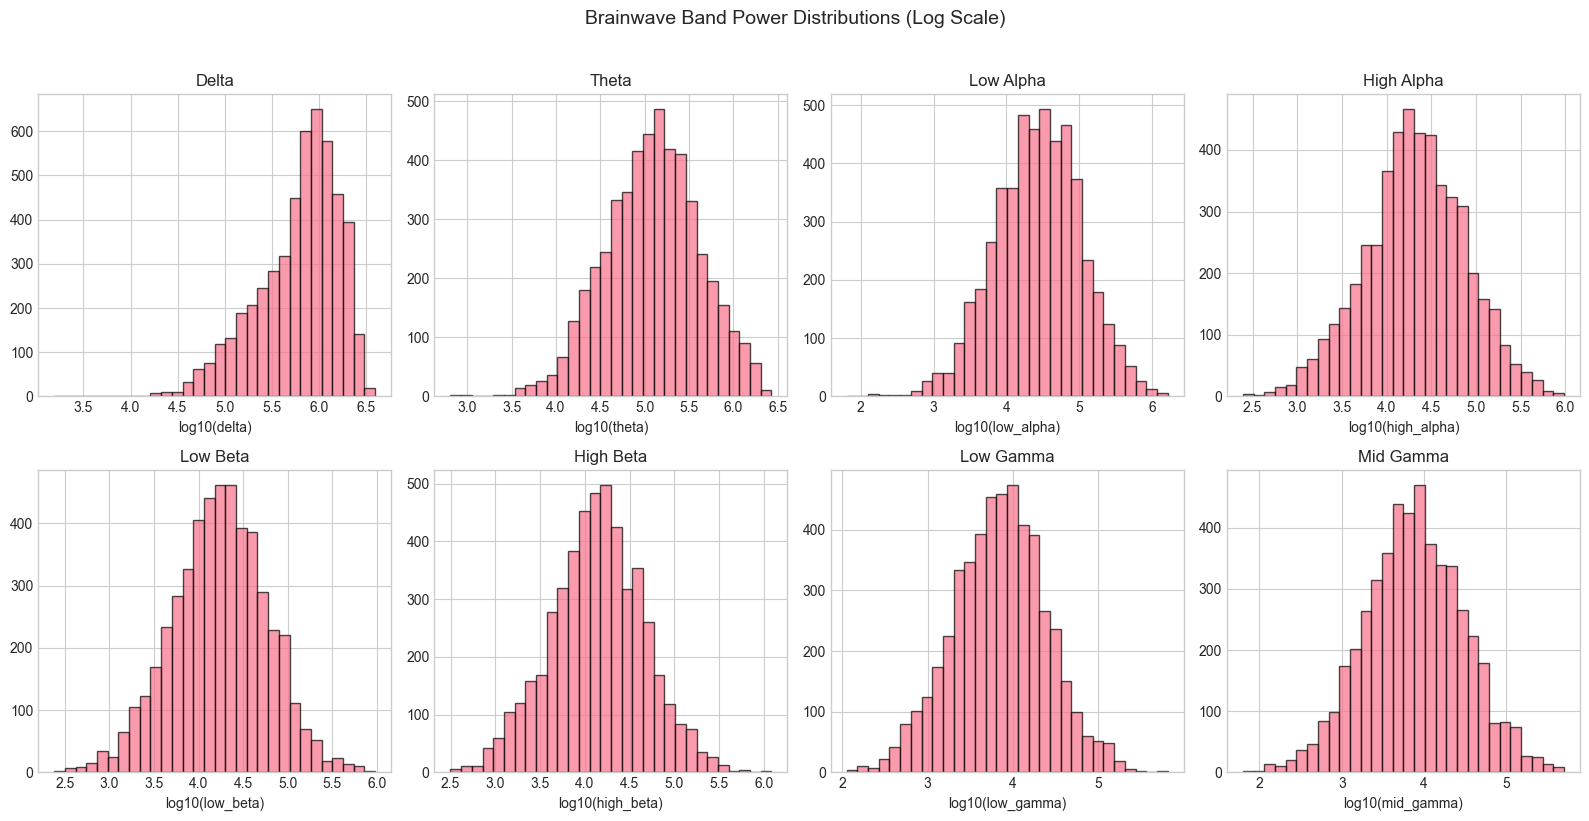

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, band in enumerate(bands):
    data = np.log10(df_good[band].replace(0, np.nan).dropna() + 1)
    axes[i].hist(data, bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(f'log10({band})')
    axes[i].set_title(band.replace('_', ' ').title())

plt.suptitle('Brainwave Band Power Distributions (Log Scale)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

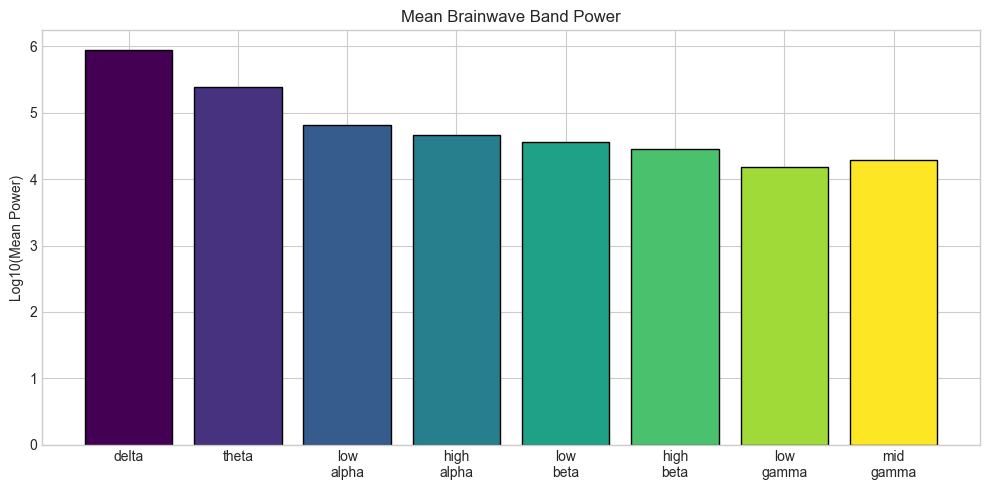

In [7]:
# Mean power comparison
band_means = df_good[bands].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(bands)))
ax.bar(range(len(bands)), np.log10(band_means + 1), color=colors, edgecolor='black')
ax.set_xticks(range(len(bands)))
ax.set_xticklabels([b.replace('_', '\n') for b in bands])
ax.set_ylabel('Log10(Mean Power)')
ax.set_title('Mean Brainwave Band Power')
plt.tight_layout()
plt.show()

## 5. Event Distribution

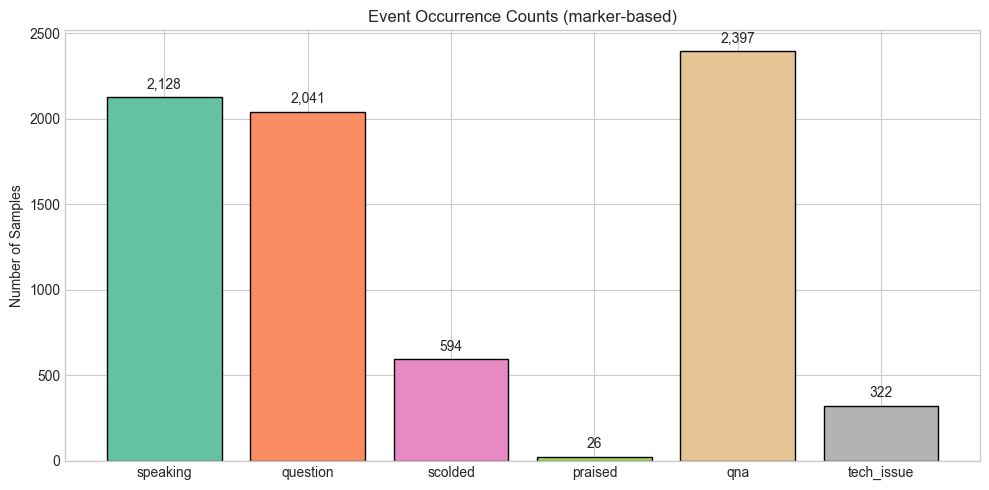

Event counts:
qna           2397
speaking      2128
question      2041
scolded        594
tech_issue     322
praised         26
dtype: int64


In [8]:
# Event counts from marker columns
event_counts = df_good[marker_events].sum()
event_counts.index = [e.replace('marker_ev_', '').replace('_active', '') for e in event_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(event_counts)))
bars = ax.bar(event_counts.index, event_counts.values, color=colors, edgecolor='black')
ax.set_ylabel('Number of Samples')
ax.set_title('Event Occurrence Counts (marker-based)')

for bar, val in zip(bars, event_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{int(val):,}', 
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()
print("Event counts:")
print(event_counts.sort_values(ascending=False))

## 6. Brainwave Changes During Events - DETAILED ANALYSIS

In [9]:
# Calculate mean band power during each event (ON vs OFF)
event_band_data = {}
for marker_event in marker_events:
    if df_good[marker_event].sum() > 10:
        on_data = df_good[df_good[marker_event] == 1][bands].mean()
        off_data = df_good[df_good[marker_event] == 0][bands].mean()
        pct_change = ((on_data - off_data) / (off_data + 1)) * 100
        event_name = marker_event.replace('marker_ev_', '').replace('_active', '')
        event_band_data[event_name] = pct_change

event_band_df = pd.DataFrame(event_band_data).T
print("Brainwave Power % Change During Events (ON vs OFF):")
event_band_df.round(1)

Brainwave Power % Change During Events (ON vs OFF):


,delta,theta,low_alpha,high_alpha,low_beta,high_beta,low_gamma,mid_gamma
speaking,7.8,-4.5,-5.7,3.3,10.2,12.0,35.5,-14.5
question,-9.3,-7.5,-9.1,-10.9,-6.0,-4.8,-7.2,14.3
scolded,-7.6,-5.3,10.3,-2.7,-0.7,-5.6,-1.5,-3.1
praised,-6.0,-13.2,8.9,40.4,23.0,82.6,106.5,9.0
qna,-9.7,-14.9,-20.7,-17.1,-13.3,-14.1,-14.4,-0.9
tech_issue,11.3,16.6,4.0,15.2,13.6,19.6,-13.9,19.0


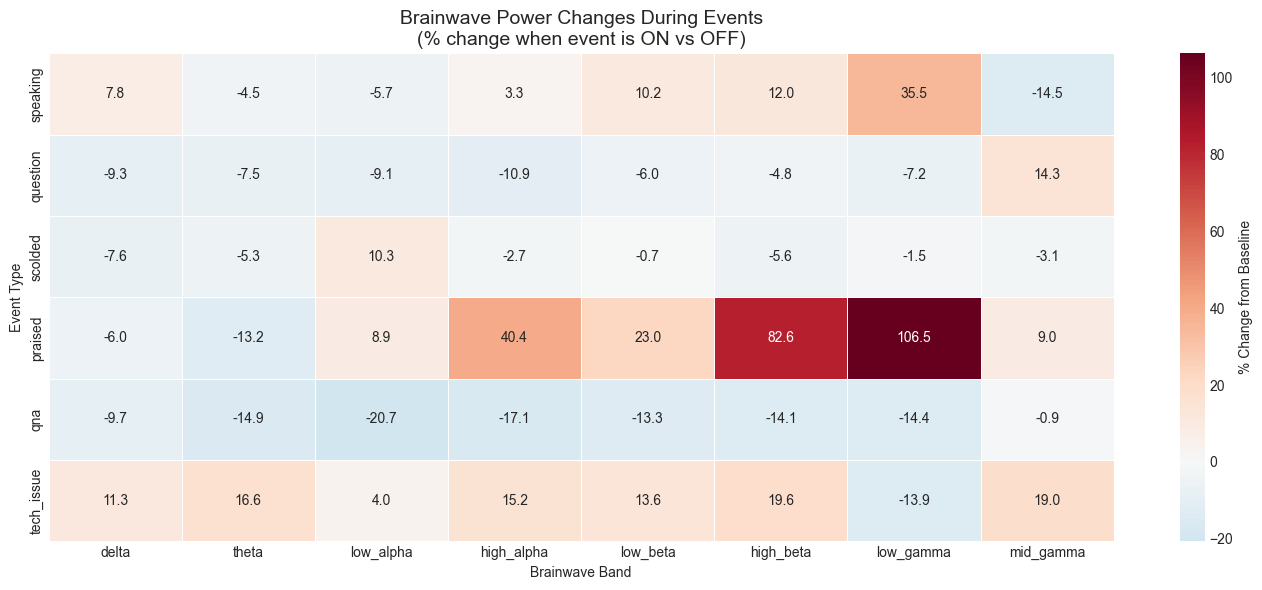

In [10]:
# Heatmap of brainwave changes
plt.figure(figsize=(14, 6))
sns.heatmap(event_band_df, annot=True, cmap='RdBu_r', center=0, fmt='.1f',
            cbar_kws={'label': '% Change from Baseline'}, linewidths=0.5)
plt.title('Brainwave Power Changes During Events\n(% change when event is ON vs OFF)', fontsize=14)
plt.xlabel('Brainwave Band')
plt.ylabel('Event Type')
plt.tight_layout()
plt.show()

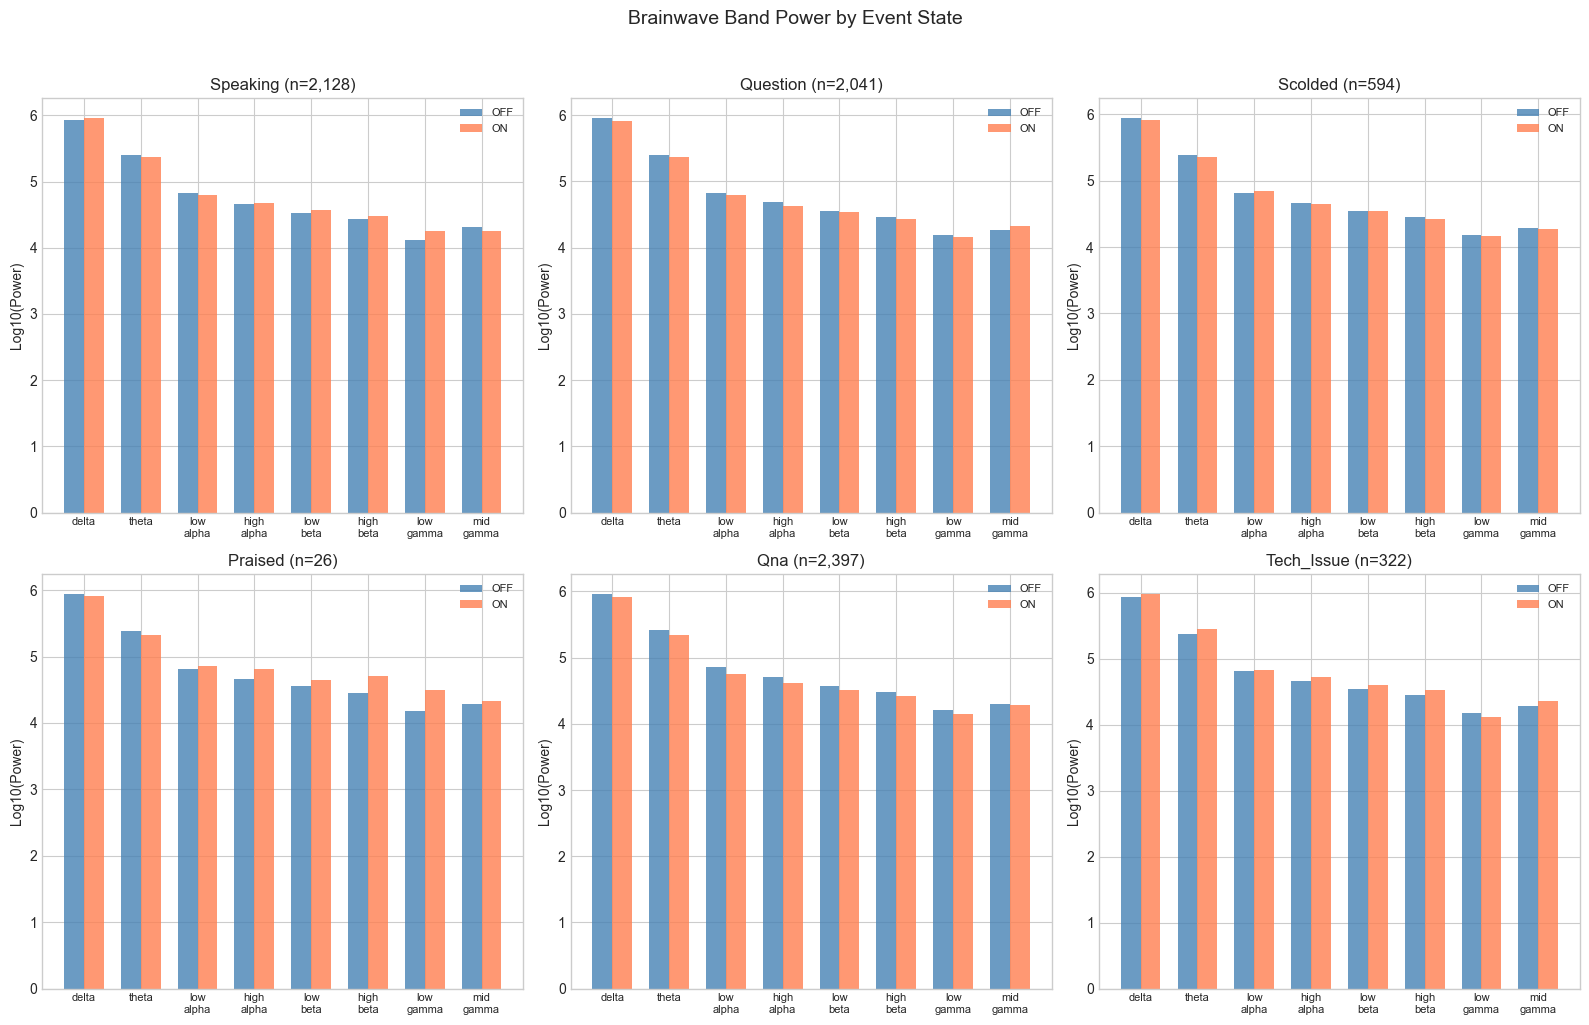

In [11]:
# Detailed bar charts for each event
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, marker_event in enumerate(marker_events):
    if df_good[marker_event].sum() > 10:
        on_means = np.log10(df_good[df_good[marker_event] == 1][bands].mean() + 1)
        off_means = np.log10(df_good[df_good[marker_event] == 0][bands].mean() + 1)
        
        x = np.arange(len(bands))
        width = 0.35
        
        axes[idx].bar(x - width/2, off_means, width, label='OFF', alpha=0.8, color='steelblue')
        axes[idx].bar(x + width/2, on_means, width, label='ON', alpha=0.8, color='coral')
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels([b.replace('_', '\n') for b in bands], fontsize=8)
        axes[idx].set_ylabel('Log10(Power)')
        event_name = marker_event.replace('marker_ev_', '').replace('_active', '').title()
        n_samples = int(df_good[marker_event].sum())
        axes[idx].set_title(f'{event_name} (n={n_samples:,})')
        axes[idx].legend(fontsize=8)

plt.suptitle('Brainwave Band Power by Event State', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Attention & Meditation During Events

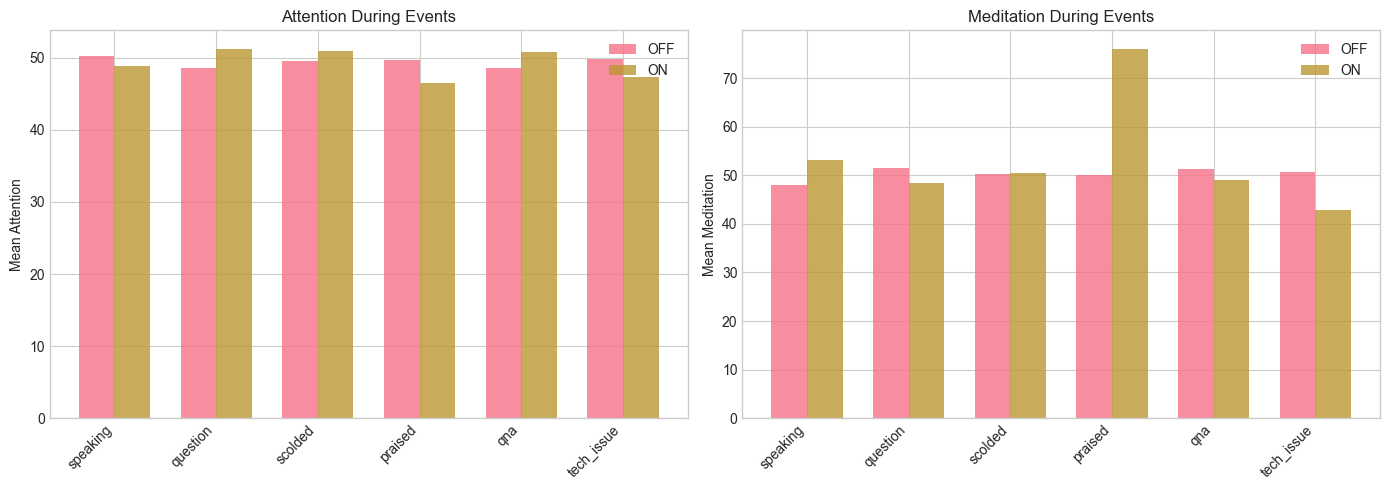

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, metric in enumerate(['attention', 'meditation']):
    event_means = []
    event_names = []
    
    for marker_event in marker_events:
        if df_good[marker_event].sum() > 10:
            on_mean = df_good[df_good[marker_event] == 1][metric].mean()
            off_mean = df_good[df_good[marker_event] == 0][metric].mean()
            event_means.append([off_mean, on_mean])
            event_names.append(marker_event.replace('marker_ev_', '').replace('_active', ''))
    
    x = np.arange(len(event_names))
    width = 0.35
    
    axes[idx].bar(x - width/2, [m[0] for m in event_means], width, label='OFF', alpha=0.8)
    axes[idx].bar(x + width/2, [m[1] for m in event_means], width, label='ON', alpha=0.8)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(event_names, rotation=45, ha='right')
    axes[idx].set_ylabel(f'Mean {metric.title()}')
    axes[idx].set_title(f'{metric.title()} During Events')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 8. Statistical Significance of Event Effects

In [13]:
# T-test for each event and metric
metrics_to_test = ['attention', 'meditation'] + bands
significance_results = []

for marker_event in marker_events:
    if df_good[marker_event].sum() > 10:
        for metric in metrics_to_test:
            on_values = df_good[df_good[marker_event] == 1][metric]
            off_values = df_good[df_good[marker_event] == 0][metric]
            
            if len(on_values) > 5 and len(off_values) > 5:
                t_stat, p_value = stats.ttest_ind(on_values, off_values)
                significance_results.append({
                    'Event': marker_event.replace('marker_ev_', '').replace('_active', ''),
                    'Metric': metric,
                    'Mean_OFF': off_values.mean(),
                    'Mean_ON': on_values.mean(),
                    'Diff': on_values.mean() - off_values.mean(),
                    'Pct_Change': ((on_values.mean() - off_values.mean()) / (off_values.mean() + 0.01)) * 100,
                    't_stat': t_stat,
                    'p_value': p_value,
                    'Significant': 'Yes' if p_value < 0.05 else 'No'
                })

sig_df = pd.DataFrame(significance_results)
print("\n=== SIGNIFICANT DIFFERENCES (p < 0.05) ===")
sig_results = sig_df[sig_df['Significant'] == 'Yes'][['Event', 'Metric', 'Mean_OFF', 'Mean_ON', 'Pct_Change', 'p_value']]
sig_results.round(4)


=== SIGNIFICANT DIFFERENCES (p < 0.05) ===


,Event,Metric,Mean_OFF,Mean_ON,Pct_Change,p_value
0,speaking,attention,50.2434,48.8689,-2.7351,0.0291
1,speaking,meditation,48.0073,53.1090,10.6247,0.0000
2,speaking,delta,842637.0238,908098.6598,7.7687,0.0005
6,speaking,low_beta,34028.3769,37496.2758,10.1912,0.0454
7,speaking,high_beta,26908.6343,30139.4469,12.0066,0.0253
8,speaking,low_gamma,13068.0654,17703.4831,35.4713,0.0000
9,speaking,mid_gamma,20890.9161,17856.6142,-14.5245,0.0058
10,question,attention,48.5724,51.2229,5.4556,0.0000
11,question,meditation,51.3936,48.4370,-5.7517,0.0000
12,question,delta,905009.9990,820828.6962,-9.3017,0.0000


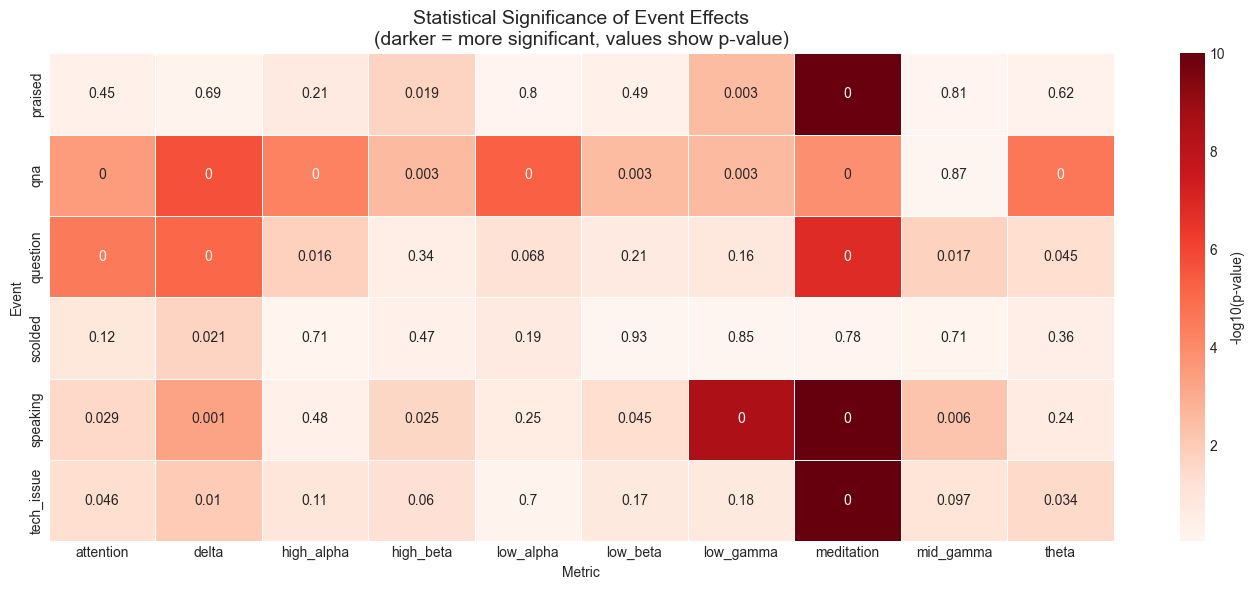

In [14]:
# Heatmap of p-values
pivot_pval = sig_df.pivot(index='Event', columns='Metric', values='p_value')

plt.figure(figsize=(14, 6))
sns.heatmap(-np.log10(pivot_pval + 1e-10), annot=pivot_pval.round(3), cmap='Reds', 
            cbar_kws={'label': '-log10(p-value)'}, linewidths=0.5)
plt.title('Statistical Significance of Event Effects\n(darker = more significant, values show p-value)', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Band Ratios Analysis

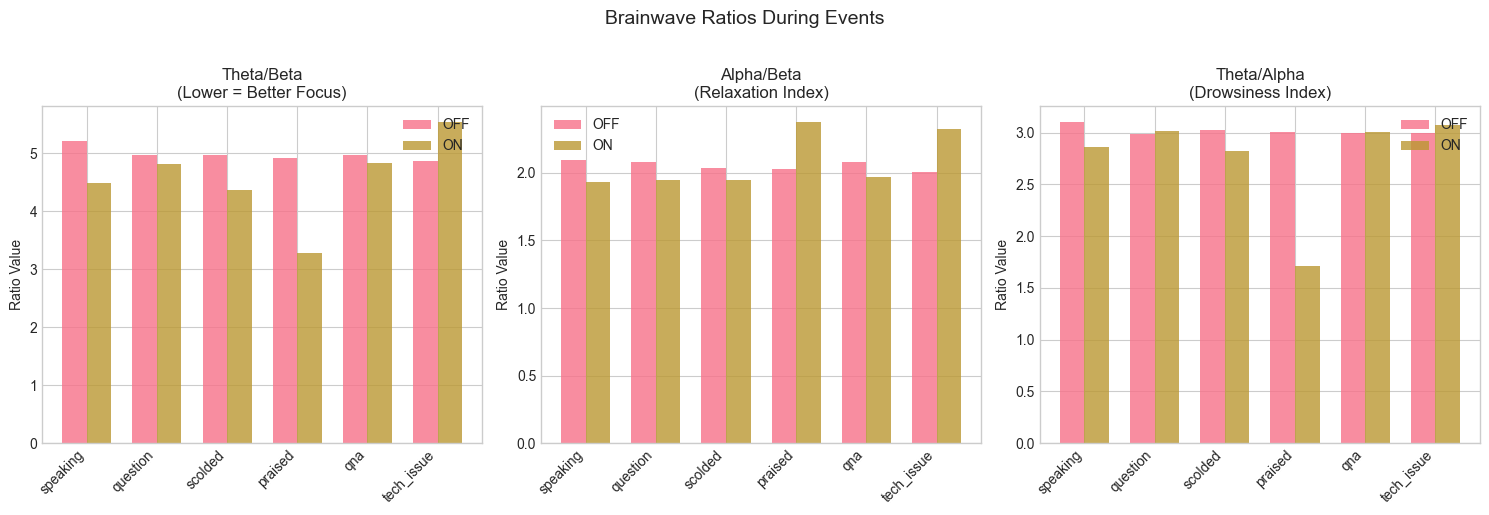

In [15]:
# Calculate key ratios
df_good['alpha_total'] = df_good['low_alpha'] + df_good['high_alpha']
df_good['beta_total'] = df_good['low_beta'] + df_good['high_beta']
df_good['theta_beta'] = df_good['theta'] / (df_good['beta_total'] + 1)
df_good['alpha_beta'] = df_good['alpha_total'] / (df_good['beta_total'] + 1)
df_good['theta_alpha'] = df_good['theta'] / (df_good['alpha_total'] + 1)

ratios = ['theta_beta', 'alpha_beta', 'theta_alpha']
ratio_labels = ['Theta/Beta\n(Lower = Better Focus)', 'Alpha/Beta\n(Relaxation Index)', 'Theta/Alpha\n(Drowsiness Index)']

# Compare ratios across events
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (ratio, label) in enumerate(zip(ratios, ratio_labels)):
    event_ratio_means = []
    event_labels = []
    
    for marker_event in marker_events:
        if df_good[marker_event].sum() > 10:
            q95 = df_good[ratio].quantile(0.95)
            on_mean = df_good[df_good[marker_event] == 1][ratio].clip(upper=q95).mean()
            off_mean = df_good[df_good[marker_event] == 0][ratio].clip(upper=q95).mean()
            event_ratio_means.append([off_mean, on_mean])
            event_labels.append(marker_event.replace('marker_ev_', '').replace('_active', ''))
    
    x = np.arange(len(event_labels))
    width = 0.35
    
    axes[idx].bar(x - width/2, [m[0] for m in event_ratio_means], width, label='OFF', alpha=0.8)
    axes[idx].bar(x + width/2, [m[1] for m in event_ratio_means], width, label='ON', alpha=0.8)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(event_labels, rotation=45, ha='right')
    axes[idx].set_ylabel('Ratio Value')
    axes[idx].set_title(label)
    axes[idx].legend()

plt.suptitle('Brainwave Ratios During Events', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Detailed Event Effects - Violin Plots

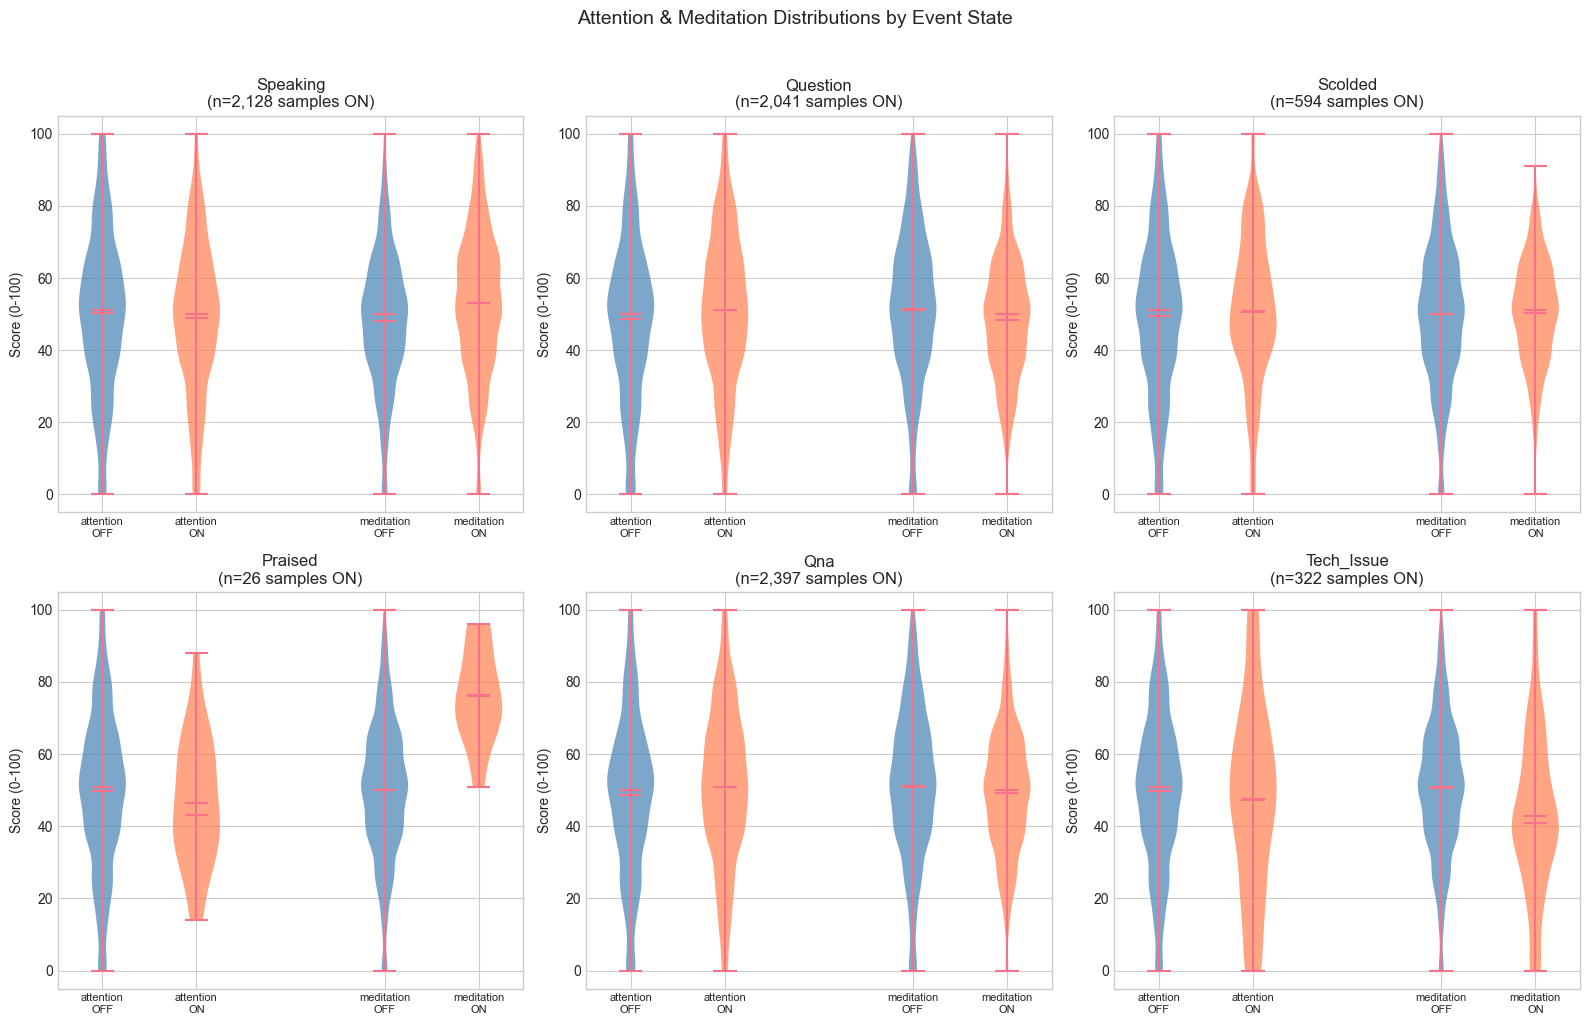

In [16]:
# Violin plots showing distribution of attention/meditation during each event
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, marker_event in enumerate(marker_events):
    if df_good[marker_event].sum() > 10:
        event_name = marker_event.replace('marker_ev_', '').replace('_active', '').title()
        
        # Prepare data for violin plot
        plot_data = []
        labels = []
        
        for metric in ['attention', 'meditation']:
            off_vals = df_good[df_good[marker_event] == 0][metric].values
            on_vals = df_good[df_good[marker_event] == 1][metric].values
            plot_data.extend([off_vals, on_vals])
            labels.extend([f'{metric}\nOFF', f'{metric}\nON'])
        
        # Create violin plot
        parts = axes[idx].violinplot(plot_data, positions=[1, 2, 4, 5], showmeans=True, showmedians=True)
        axes[idx].set_xticks([1, 2, 4, 5])
        axes[idx].set_xticklabels(labels, fontsize=8)
        axes[idx].set_ylabel('Score (0-100)')
        n_on = int(df_good[marker_event].sum())
        axes[idx].set_title(f'{event_name}\n(n={n_on:,} samples ON)')
        
        # Color the violins
        for i, pc in enumerate(parts['bodies']):
            if i % 2 == 0:
                pc.set_facecolor('steelblue')
            else:
                pc.set_facecolor('coral')
            pc.set_alpha(0.7)

plt.suptitle('Attention & Meditation Distributions by Event State', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Event Effect Summary Table (% Change)

In [17]:
# Comprehensive table showing % change for all metrics during each event
print("=" * 80)
print("         PERCENTAGE CHANGE IN EEG METRICS DURING EVENTS")
print("         (Positive = Higher during event, Negative = Lower)")
print("=" * 80)

# Calculate detailed stats for each event
event_effect_data = []
for marker_event in marker_events:
    if df_good[marker_event].sum() > 10:
        event_name = marker_event.replace('marker_ev_', '').replace('_active', '')
        n_on = int(df_good[marker_event].sum())
        n_off = int((df_good[marker_event] == 0).sum())
        
        row = {'Event': event_name, 'N_ON': n_on, 'N_OFF': n_off}
        
        for metric in ['attention', 'meditation'] + bands:
            on_mean = df_good[df_good[marker_event] == 1][metric].mean()
            off_mean = df_good[df_good[marker_event] == 0][metric].mean()
            pct_change = ((on_mean - off_mean) / (off_mean + 0.01)) * 100
            row[metric] = pct_change
        
        event_effect_data.append(row)

event_effect_df = pd.DataFrame(event_effect_data)
event_effect_df = event_effect_df.set_index('Event')

# Display the table
print("\n--- Sample Counts ---")
print(event_effect_df[['N_ON', 'N_OFF']].to_string())

print("\n--- % Change in Attention & Meditation ---")
print(event_effect_df[['attention', 'meditation']].round(2).to_string())

print("\n--- % Change in Brainwave Bands ---")
print(event_effect_df[bands].round(2).to_string())

         PERCENTAGE CHANGE IN EEG METRICS DURING EVENTS
         (Positive = Higher during event, Negative = Lower)

--- Sample Counts ---
            N_ON  N_OFF
Event                  
speaking    2128   2860
question    2041   2947
scolded      594   4394
praised       26   4962
qna         2397   2591
tech_issue   322   4666

--- % Change in Attention & Meditation ---
            attention  meditation
Event                            
speaking        -2.74       10.62
question         5.46       -5.75
scolded          2.98        0.49
praised         -6.54       51.84
qna              4.60       -4.12
tech_issue      -5.09      -15.30

--- % Change in Brainwave Bands ---
            delta  theta  low_alpha  high_alpha  low_beta  high_beta  low_gamma  mid_gamma
Event                                                                                     
speaking     7.77  -4.46      -5.72        3.34     10.19      12.01      35.47     -14.52
question    -9.30  -7.53      -9.06      -1

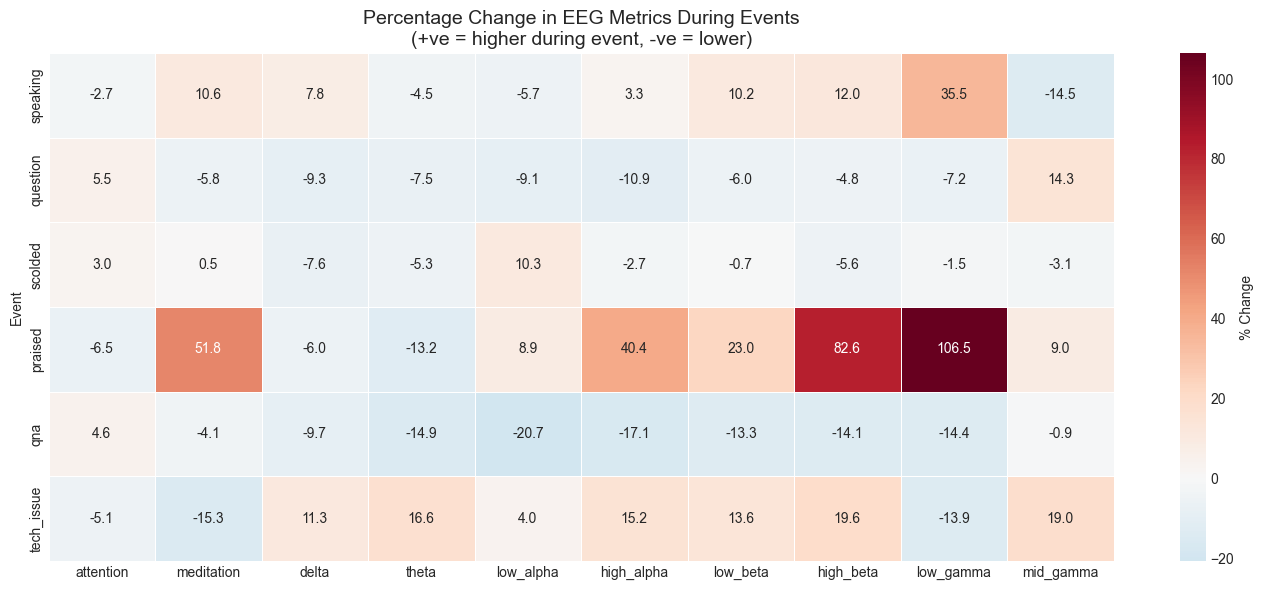


                    COMPLETE EVENT EFFECTS TABLE
            attention  meditation  delta  theta  low_alpha  high_alpha  low_beta  high_beta  low_gamma  mid_gamma
Event                                                                                                            
speaking         -2.7        10.6    7.8   -4.5       -5.7         3.3      10.2       12.0       35.5      -14.5
question          5.5        -5.8   -9.3   -7.5       -9.1       -10.9      -6.0       -4.8       -7.2       14.3
scolded           3.0         0.5   -7.6   -5.3       10.3        -2.7      -0.7       -5.6       -1.5       -3.1
praised          -6.5        51.8   -6.0  -13.2        8.9        40.4      23.0       82.6      106.5        9.0
qna               4.6        -4.1   -9.7  -14.9      -20.7       -17.1     -13.3      -14.1      -14.4       -0.9
tech_issue       -5.1       -15.3   11.3   16.6        4.0        15.2      13.6       19.6      -13.9       19.0


In [18]:
# Create a styled DataFrame showing the percentage changes with color coding
pct_change_display = event_effect_df[['attention', 'meditation'] + bands].round(1)

# Display as heatmap for visual comparison
plt.figure(figsize=(14, 6))
sns.heatmap(pct_change_display, annot=True, cmap='RdBu_r', center=0, fmt='.1f',
            cbar_kws={'label': '% Change'}, linewidths=0.5)
plt.title('Percentage Change in EEG Metrics During Events\n(+ve = higher during event, -ve = lower)', fontsize=14)
plt.tight_layout()
plt.show()

# Show as formatted table
print("\n" + "=" * 80)
print("                    COMPLETE EVENT EFFECTS TABLE")
print("=" * 80)
display_cols = ['attention', 'meditation'] + bands
print(pct_change_display.to_string())

## 12. Event Interaction Analysis

In [ ]:
# Analyze what happens when multiple events are active
df_good['num_events_active'] = df_good[marker_events].sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribution of number of concurrent events
event_counts = df_good['num_events_active'].value_counts().sort_index()
axes[0].bar(event_counts.index, event_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of Active Events')
axes[0].set_ylabel('Sample Count')
axes[0].set_title('Distribution of Concurrent Events')
for i, (x, y) in enumerate(zip(event_counts.index, event_counts.values)):
    axes[0].text(x, y + 50, f'{y:,}', ha='center', fontsize=9)

# Attention by number of active events
event_attention = df_good.groupby('num_events_active')['attention'].agg(['mean', 'std']).reset_index()
axes[1].bar(event_attention['num_events_active'], event_attention['mean'], 
            yerr=event_attention['std']/2, color='coral', edgecolor='black', capsize=5)
axes[1].set_xlabel('Number of Active Events')
axes[1].set_ylabel('Mean Attention')
axes[1].set_title('Attention by Event Load')

# Meditation by number of active events
event_meditation = df_good.groupby('num_events_active')['meditation'].agg(['mean', 'std']).reset_index()
axes[2].bar(event_meditation['num_events_active'], event_meditation['mean'], 
            yerr=event_meditation['std']/2, color='purple', edgecolor='black', capsize=5)
axes[2].set_xlabel('Number of Active Events')
axes[2].set_ylabel('Mean Meditation')
axes[2].set_title('Meditation by Event Load')

plt.suptitle('Impact of Multiple Concurrent Events', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

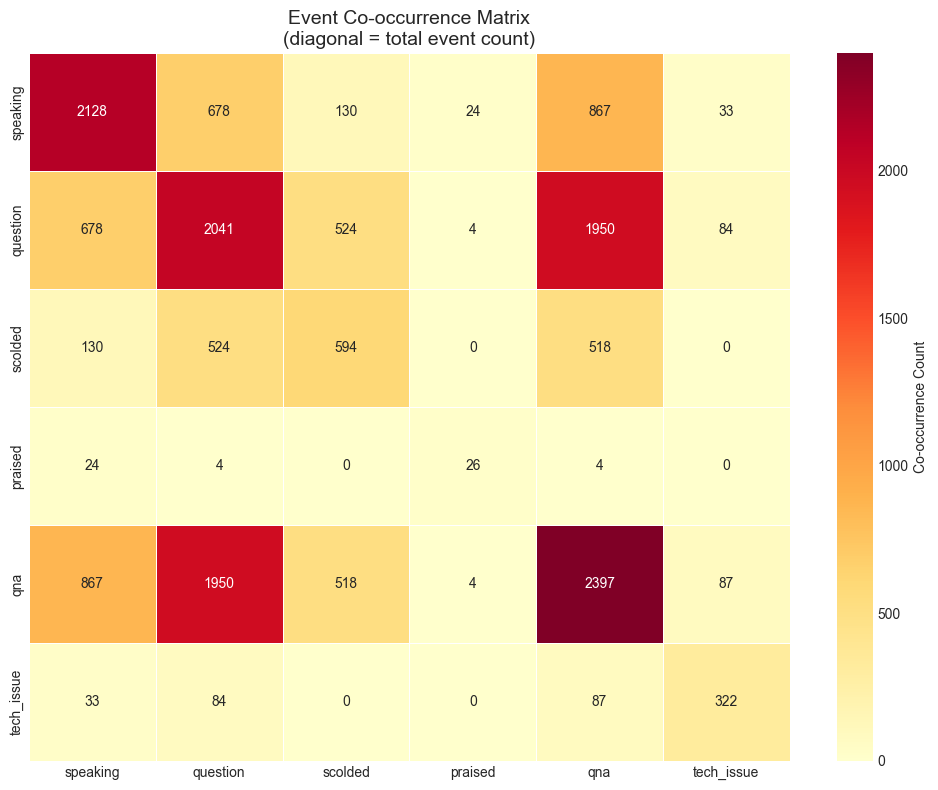

In [22]:
# Event co-occurrence matrix
cooccur = np.zeros((len(marker_events), len(marker_events)))
event_names_short = [e.replace('marker_ev_', '').replace('_active', '') for e in marker_events]

for i, ev1 in enumerate(marker_events):
    for j, ev2 in enumerate(marker_events):
        if i == j:
            cooccur[i, j] = df_good[ev1].sum()
        else:
            cooccur[i, j] = ((df_good[ev1] == 1) & (df_good[ev2] == 1)).sum()

plt.figure(figsize=(10, 8))
sns.heatmap(cooccur, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=event_names_short, yticklabels=event_names_short,
            cbar_kws={'label': 'Co-occurrence Count'}, linewidths=0.5)
plt.title('Event Co-occurrence Matrix\n(diagonal = total event count)', fontsize=14)
plt.tight_layout()
plt.show()

## 13. Event Effect Comparison - Radar Chart

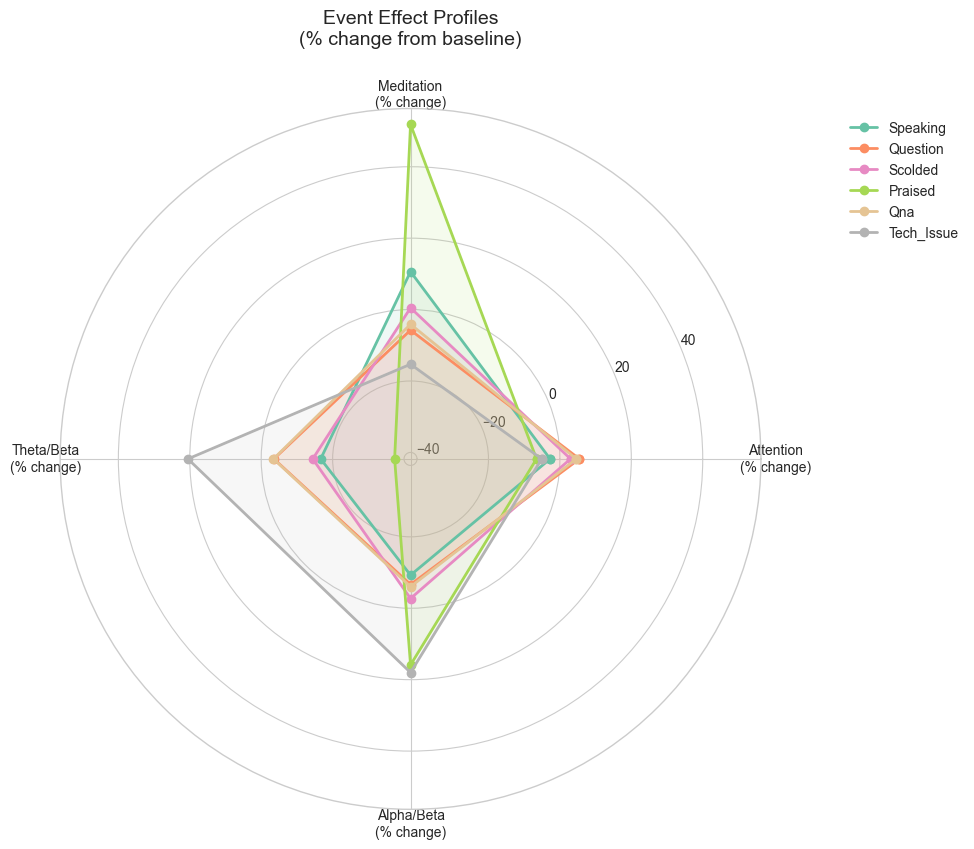

In [23]:
from math import pi

# Prepare normalized data for radar chart
metrics_radar = ['attention', 'meditation', 'theta_beta', 'alpha_beta']

# Calculate mean for each event
radar_data = {}
for marker_event in marker_events:
    if df_good[marker_event].sum() > 10:
        event_name = marker_event.replace('marker_ev_', '').replace('_active', '')
        on_data = df_good[df_good[marker_event] == 1]
        off_data = df_good[df_good[marker_event] == 0]
        
        # Calculate % change from baseline
        changes = []
        for metric in metrics_radar:
            off_mean = off_data[metric].mean()
            on_mean = on_data[metric].mean()
            pct_change = ((on_mean - off_mean) / (abs(off_mean) + 0.01)) * 100
            changes.append(pct_change)
        radar_data[event_name] = changes

# Create radar chart
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Number of metrics
N = len(metrics_radar)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Close the loop

# Plot each event
colors = plt.cm.Set2(np.linspace(0, 1, len(radar_data)))
for idx, (event, values) in enumerate(radar_data.items()):
    values += values[:1]  # Close the loop
    ax.plot(angles, values, 'o-', linewidth=2, label=event.title(), color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

# Set labels
metric_labels = ['Attention\n(% change)', 'Meditation\n(% change)', 
                 'Theta/Beta\n(% change)', 'Alpha/Beta\n(% change)']
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=10)

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.title('Event Effect Profiles\n(% change from baseline)', fontsize=14, y=1.08)
plt.tight_layout()
plt.show()

## 14. Event Duration & Intensity Analysis

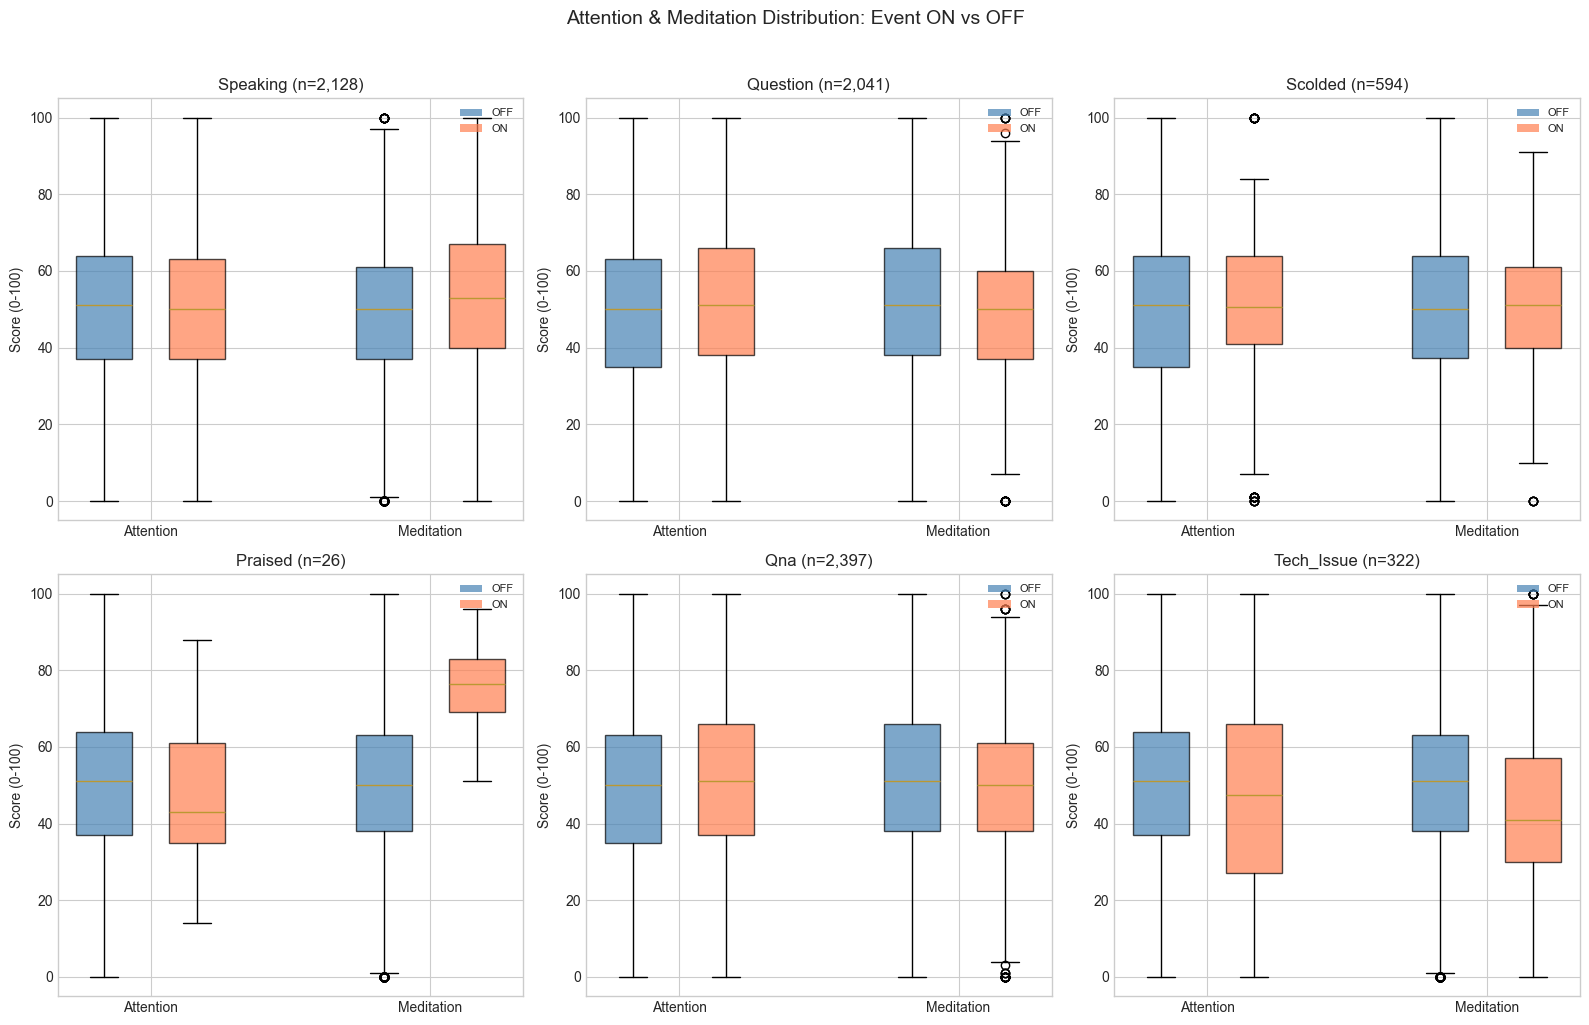

In [24]:
# Analyze how metrics evolve over event duration within sessions
# Group consecutive event samples as "event episodes"

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, marker_event in enumerate(marker_events):
    event_name = marker_event.replace('marker_ev_', '').replace('_active', '').title()
    
    if df_good[marker_event].sum() > 10:
        # Get samples during event
        event_samples = df_good[df_good[marker_event] == 1].copy()
        
        if len(event_samples) > 0:
            # Create distribution plot
            data_to_plot = [
                df_good[df_good[marker_event] == 0]['attention'].values,
                event_samples['attention'].values,
                df_good[df_good[marker_event] == 0]['meditation'].values,
                event_samples['meditation'].values
            ]
            
            bp = axes[idx].boxplot(data_to_plot, positions=[1, 2, 4, 5], widths=0.6, patch_artist=True)
            
            # Color boxes
            colors_box = ['steelblue', 'coral', 'steelblue', 'coral']
            for patch, color in zip(bp['boxes'], colors_box):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            axes[idx].set_xticks([1.5, 4.5])
            axes[idx].set_xticklabels(['Attention', 'Meditation'])
            axes[idx].set_ylabel('Score (0-100)')
            
            # Add legend
            from matplotlib.patches import Patch
            legend_elements = [Patch(facecolor='steelblue', alpha=0.7, label='OFF'),
                              Patch(facecolor='coral', alpha=0.7, label='ON')]
            axes[idx].legend(handles=legend_elements, loc='upper right', fontsize=8)
            
            n_on = len(event_samples)
            axes[idx].set_title(f'{event_name} (n={n_on:,})')

plt.suptitle('Attention & Meditation Distribution: Event ON vs OFF', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 15. Emotion Analysis

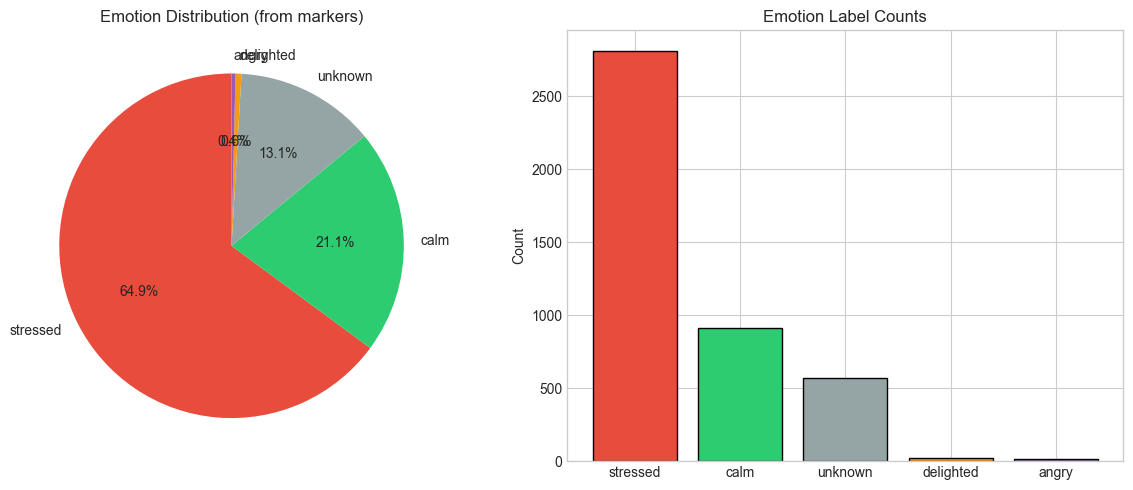

Emotion counts:
marker_emotion
stressed     2809
calm          913
unknown       567
delighted      24
angry          16
Name: count, dtype: int64


In [25]:
# Emotion distribution from marker_emotion column
emotion_counts = df_good['marker_emotion'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
colors = {'calm': '#2ecc71', 'stressed': '#e74c3c', 'delighted': '#f39c12', 'angry': '#9b59b6', 'unknown': '#95a5a6'}
emotion_colors = [colors.get(e, '#95a5a6') for e in emotion_counts.index]
axes[0].pie(emotion_counts, labels=emotion_counts.index, autopct='%1.1f%%', colors=emotion_colors, startangle=90)
axes[0].set_title('Emotion Distribution (from markers)')

# Bar chart
axes[1].bar(emotion_counts.index, emotion_counts.values, color=emotion_colors, edgecolor='black')
axes[1].set_ylabel('Count')
axes[1].set_title('Emotion Label Counts')

plt.tight_layout()
plt.show()

print("Emotion counts:")
print(emotion_counts)

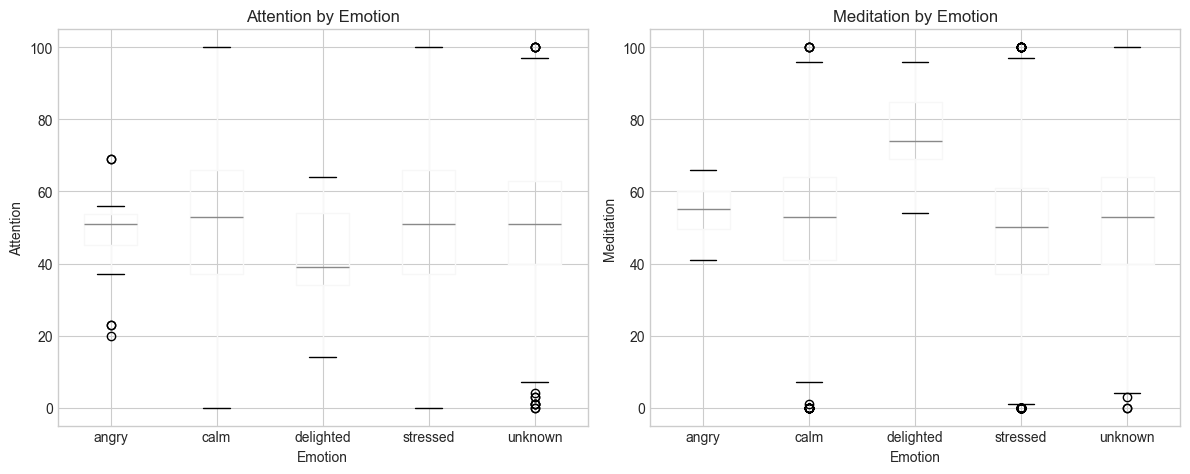

In [26]:
# EEG metrics by emotion
df_with_emotion = df_good[df_good['marker_emotion'].notna()].copy()

if len(df_with_emotion) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    df_with_emotion.boxplot(column='attention', by='marker_emotion', ax=axes[0])
    axes[0].set_xlabel('Emotion')
    axes[0].set_ylabel('Attention')
    axes[0].set_title('Attention by Emotion')
    plt.suptitle('')
    
    df_with_emotion.boxplot(column='meditation', by='marker_emotion', ax=axes[1])
    axes[1].set_xlabel('Emotion')
    axes[1].set_ylabel('Meditation')
    axes[1].set_title('Meditation by Emotion')
    plt.suptitle('')
    
    plt.tight_layout()
    plt.show()

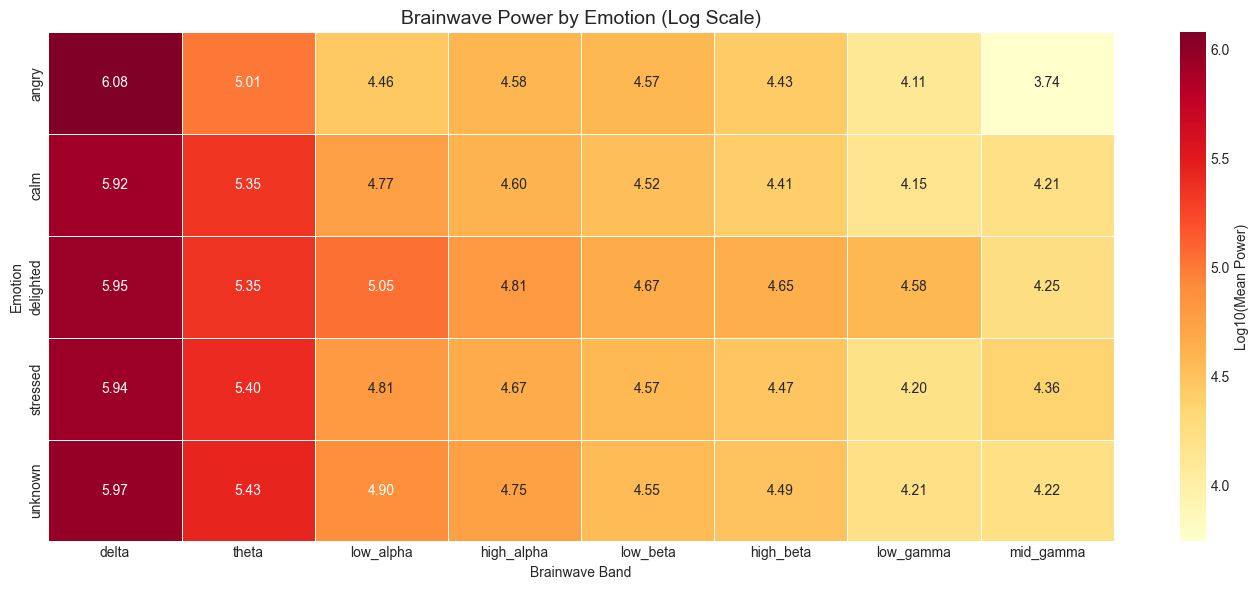

In [27]:
# Brainwave bands by emotion
if len(df_with_emotion) > 0:
    emotion_band_means = df_with_emotion.groupby('marker_emotion')[bands].mean()
    
    plt.figure(figsize=(14, 6))
    sns.heatmap(np.log10(emotion_band_means + 1), annot=True, cmap='YlOrRd', fmt='.2f',
                cbar_kws={'label': 'Log10(Mean Power)'}, linewidths=0.5)
    plt.title('Brainwave Power by Emotion (Log Scale)', fontsize=14)
    plt.xlabel('Brainwave Band')
    plt.ylabel('Emotion')
    plt.tight_layout()
    plt.show()

## 16. Correlation Matrix

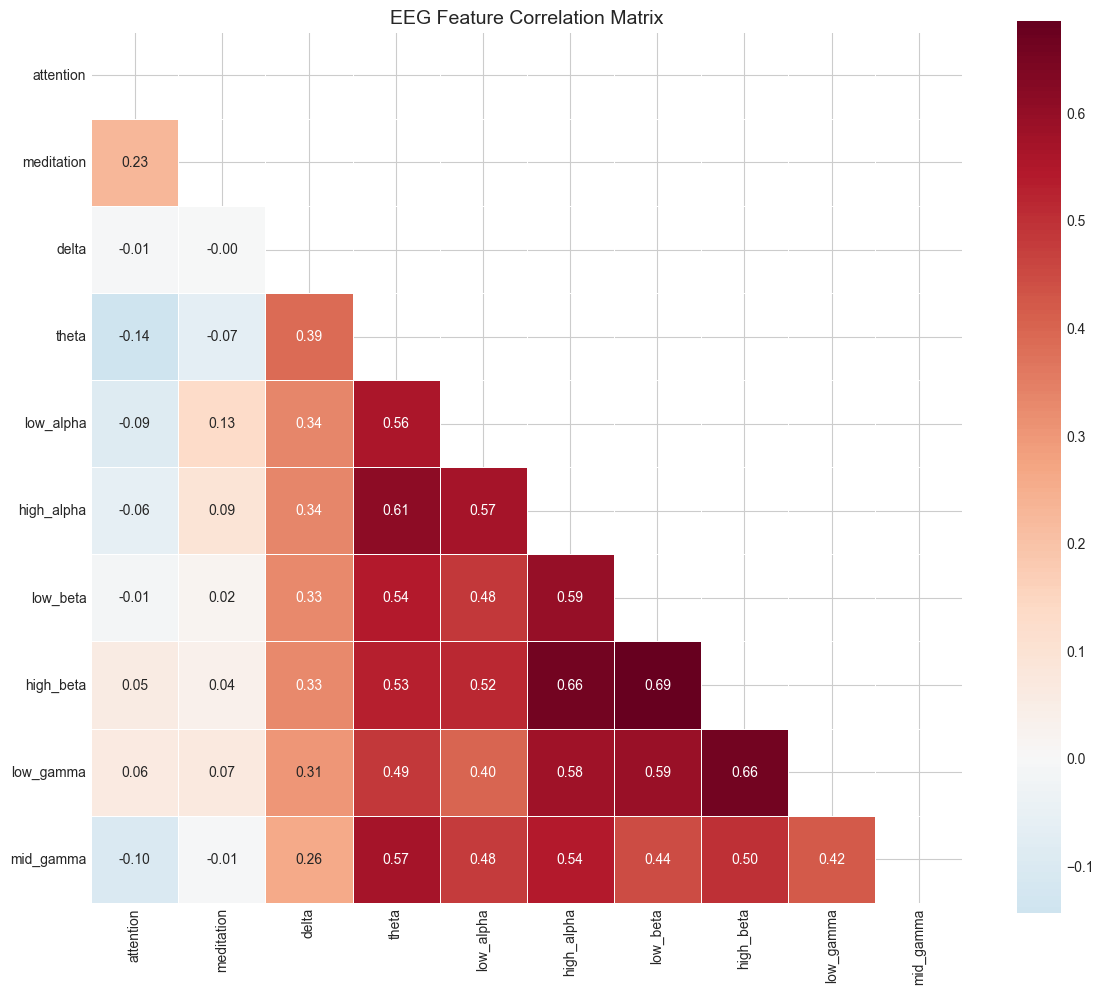

In [28]:
corr_cols = ['attention', 'meditation'] + bands
corr_matrix = df_good[corr_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5, mask=mask)
plt.title('EEG Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## 17. Session Comparison

In [29]:
# Session-level summary
session_summary = df_good.groupby('session_id').agg({
    'attention': ['mean', 'std', 'max'],
    'meditation': ['mean', 'std', 'max'],
    'theta': 'mean',
    'low_alpha': 'mean',
    'high_beta': 'mean'
}).round(2)

session_summary.columns = ['_'.join(col) for col in session_summary.columns]
session_summary = session_summary.sort_values('attention_mean', ascending=False)

print("Top 10 Sessions by Mean Attention:")
session_summary.head(10)

Top 10 Sessions by Mean Attention:


,attention_mean,attention_std,attention_max,meditation_mean,meditation_std,meditation_max,theta_mean,low_alpha_mean,high_beta_mean
session_id,,,,,,,,,
0067,65.70,16.88,100,48.29,12.40,77,187014.57,46196.94,22932.85
20,58.33,28.81,90,60.61,32.21,100,442161.56,182353.56,98956.00
0065,57.98,22.67,100,41.35,18.23,81,216180.10,48790.36,29820.68
S20260330_123803,57.85,25.34,100,46.21,11.88,69,262145.81,81188.64,23959.32
0061,56.34,21.43,100,43.75,20.48,100,227489.99,47679.23,15671.27
038,55.87,18.88,100,58.32,16.01,96,166312.40,45316.93,17535.77
S20260330_123710,54.62,20.05,88,55.04,21.06,100,278405.49,43017.80,22285.42
19,52.27,23.60,100,49.81,15.95,91,231830.33,62292.84,18294.53
S20260330_115300,52.06,17.41,87,67.06,20.27,94,239128.72,28470.89,19723.22


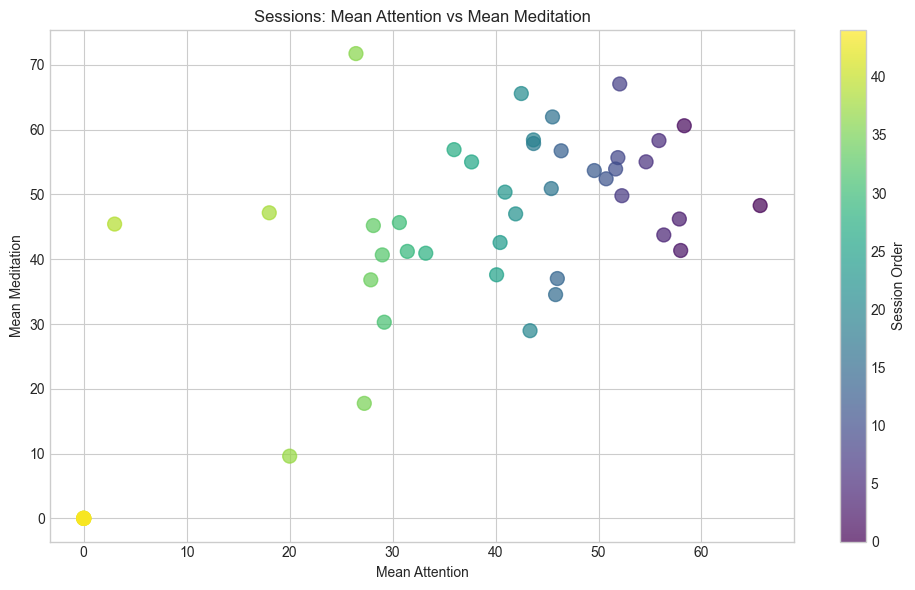

In [30]:
# Session scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(session_summary['attention_mean'], session_summary['meditation_mean'],
                     s=100, alpha=0.7, c=range(len(session_summary)), cmap='viridis')

ax.set_xlabel('Mean Attention')
ax.set_ylabel('Mean Meditation')
ax.set_title('Sessions: Mean Attention vs Mean Meditation')
plt.colorbar(scatter, label='Session Order')
plt.tight_layout()
plt.show()

## 18. Summary & Key Findings

In [31]:
print("=" * 70)
print("                    KEY FINDINGS FROM EEG DATA ANALYSIS")
print("=" * 70)

# Data quality
print(f"\n1. DATA OVERVIEW")
print(f"   - Total data points: {len(df):,}")
print(f"   - Good signal data: {len(df_good):,} ({len(df_good)/len(df)*100:.1f}%)")
print(f"   - Sessions: {df['session_id'].nunique()}")

# Baseline metrics
print(f"\n2. BASELINE METRICS (good signal)")
print(f"   - Attention: {df_good['attention'].mean():.1f} ± {df_good['attention'].std():.1f}")
print(f"   - Meditation: {df_good['meditation'].mean():.1f} ± {df_good['meditation'].std():.1f}")

# Most significant event effects
print(f"\n3. SIGNIFICANT EVENT EFFECTS ON ATTENTION")
att_effects = sig_df[(sig_df['Metric'] == 'attention') & (sig_df['Significant'] == 'Yes')]
for _, row in att_effects.iterrows():
    direction = 'increases' if row['Diff'] > 0 else 'decreases'
    print(f"   - {row['Event'].title()}: {direction} attention by {abs(row['Diff']):.1f} points (p={row['p_value']:.4f})")

print(f"\n4. SIGNIFICANT EVENT EFFECTS ON MEDITATION")
med_effects = sig_df[(sig_df['Metric'] == 'meditation') & (sig_df['Significant'] == 'Yes')]
for _, row in med_effects.iterrows():
    direction = 'increases' if row['Diff'] > 0 else 'decreases'
    print(f"   - {row['Event'].title()}: {direction} meditation by {abs(row['Diff']):.1f} points (p={row['p_value']:.4f})")

# Emotion insights
if len(df_with_emotion) > 0:
    print(f"\n5. EMOTION INSIGHTS")
    emotion_att = df_with_emotion.groupby('marker_emotion')['attention'].mean().sort_values(ascending=False)
    print(f"   - Highest attention during: {emotion_att.index[0]} ({emotion_att.iloc[0]:.1f})")
    print(f"   - Lowest attention during: {emotion_att.index[-1]} ({emotion_att.iloc[-1]:.1f})")

print("\n" + "=" * 70)

# Save summary
session_summary.to_csv('session_summary.csv')
print("\nSession summary saved to session_summary.csv")

                    KEY FINDINGS FROM EEG DATA ANALYSIS

1. DATA OVERVIEW
   - Total data points: 11,945
   - Good signal data: 4,988 (41.8%)
   - Sessions: 65

2. BASELINE METRICS (good signal)
   - Attention: 49.7 ± 22.0
   - Meditation: 50.2 ± 19.6

3. SIGNIFICANT EVENT EFFECTS ON ATTENTION
   - Speaking: decreases attention by 1.4 points (p=0.0291)
   - Question: increases attention by 2.7 points (p=0.0000)
   - Qna: increases attention by 2.2 points (p=0.0003)
   - Tech_Issue: decreases attention by 2.5 points (p=0.0456)

4. SIGNIFICANT EVENT EFFECTS ON MEDITATION
   - Speaking: increases meditation by 5.1 points (p=0.0000)
   - Question: decreases meditation by 3.0 points (p=0.0000)
   - Praised: increases meditation by 26.0 points (p=0.0000)
   - Qna: decreases meditation by 2.1 points (p=0.0001)
   - Tech_Issue: decreases meditation by 7.8 points (p=0.0000)

5. EMOTION INSIGHTS
   - Highest attention during: unknown (51.3)
   - Lowest attention during: delighted (41.5)


Sessio